# XGBoost

## Importar Dados

In [1]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## XGboost - Default

In [2]:
import xgboost as xgb

xgboost = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.7838
Precisão: 0.7538
Recall: 0.7461
F1-Score: 0.7496
MCC: 0.4999
AUC: 0.8459
--------------------------------------------------


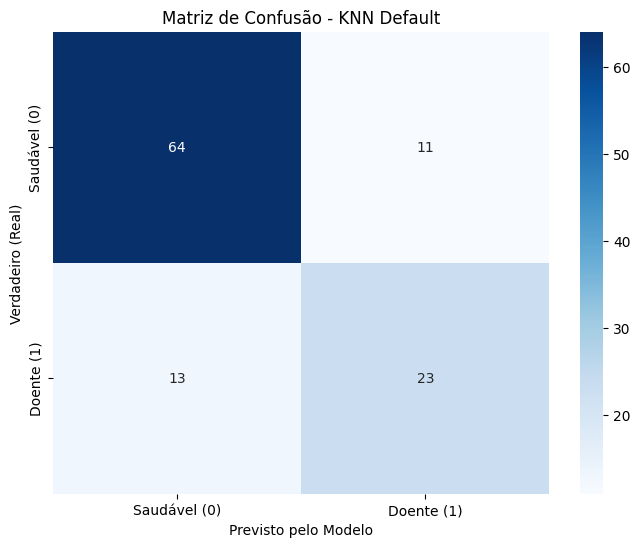

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = xgboost.predict(X_test)
y_prob_def = xgboost.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## XGBoost - Melhorado

In [4]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hiperparâmetros recomendados para XGBoost
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'objective': 'binary:logistic',
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'random_state': 14
    }

    # Inicializa o classificador
    clf = xgb.XGBClassifier(**params)

    # Cross-validation
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_xgb = xgb.XGBClassifier(**study.best_params, objective='binary:logistic', n_jobs=-1, random_state=14)
best_xgb.fit(X_train, y_train.values.ravel())

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-16 11:34:05,549] A new study created in memory with name: no-name-805c851e-3dab-4299-9256-23d0a9b720ac
Best trial: 0. Best value: 0.794947:   1%|          | 1/100 [00:00<00:43,  2.28it/s]

[I 2026-08-16 11:34:05,987] Trial 0 finished with value: 0.7949472096530921 and parameters: {'n_estimators': 209, 'max_depth': 5, 'learning_rate': 0.07592145638647625, 'subsample': 0.6973472556331324, 'colsample_bytree': 0.540373188908244, 'gamma': 2.377062371019556}. Best is trial 0 with value: 0.7949472096530921.


Best trial: 1. Best value: 0.802489:   2%|▏         | 2/100 [00:01<01:07,  1.44it/s]

[I 2026-08-16 11:34:06,855] Trial 1 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 202, 'max_depth': 10, 'learning_rate': 0.01786259287283034, 'subsample': 0.5978408051640903, 'colsample_bytree': 0.8467390981613596, 'gamma': 0.7489152466202403}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   3%|▎         | 3/100 [00:01<01:03,  1.54it/s]

[I 2026-08-16 11:34:07,459] Trial 2 finished with value: 0.7871040723981899 and parameters: {'n_estimators': 217, 'max_depth': 3, 'learning_rate': 0.08690645287583641, 'subsample': 0.8857523757726533, 'colsample_bytree': 0.7861544891275052, 'gamma': 0.34156618780905923}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   4%|▍         | 4/100 [00:02<00:59,  1.62it/s]

[I 2026-08-16 11:34:08,024] Trial 3 finished with value: 0.7833333333333333 and parameters: {'n_estimators': 188, 'max_depth': 8, 'learning_rate': 0.019713035389710056, 'subsample': 0.9004921986807962, 'colsample_bytree': 0.708756647599114, 'gamma': 2.342361243373314}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   5%|▌         | 5/100 [00:02<00:48,  1.96it/s]

[I 2026-08-16 11:34:08,344] Trial 4 finished with value: 0.775339366515837 and parameters: {'n_estimators': 167, 'max_depth': 8, 'learning_rate': 0.03195759680833099, 'subsample': 0.8459511320378572, 'colsample_bytree': 0.942855224766694, 'gamma': 4.071220099667904}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   6%|▌         | 6/100 [00:03<00:38,  2.44it/s]

[I 2026-08-16 11:34:08,563] Trial 5 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 65, 'max_depth': 4, 'learning_rate': 0.022361066382423595, 'subsample': 0.5174972457947309, 'colsample_bytree': 0.6357057563304126, 'gamma': 0.6644332141733267}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   7%|▋         | 7/100 [00:03<00:32,  2.85it/s]

[I 2026-08-16 11:34:08,789] Trial 6 finished with value: 0.798868778280543 and parameters: {'n_estimators': 84, 'max_depth': 9, 'learning_rate': 0.19577120205871343, 'subsample': 0.8708705925041219, 'colsample_bytree': 0.8770761359240609, 'gamma': 0.7446111276565565}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   8%|▊         | 8/100 [00:03<00:36,  2.53it/s]

[I 2026-08-16 11:34:09,281] Trial 7 finished with value: 0.787028657616893 and parameters: {'n_estimators': 253, 'max_depth': 9, 'learning_rate': 0.027119995461435214, 'subsample': 0.5541784123418649, 'colsample_bytree': 0.7748075258716076, 'gamma': 2.000812783515805}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:   9%|▉         | 9/100 [00:04<00:33,  2.71it/s]

[I 2026-08-16 11:34:09,591] Trial 8 finished with value: 0.7908748114630468 and parameters: {'n_estimators': 154, 'max_depth': 9, 'learning_rate': 0.018185104898330605, 'subsample': 0.678234062653292, 'colsample_bytree': 0.8155314977141581, 'gamma': 4.583556605567588}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  10%|█         | 10/100 [00:04<00:33,  2.68it/s]

[I 2026-08-16 11:34:09,975] Trial 9 finished with value: 0.775339366515837 and parameters: {'n_estimators': 208, 'max_depth': 9, 'learning_rate': 0.07130999043265687, 'subsample': 0.99159278478296, 'colsample_bytree': 0.7203023707231473, 'gamma': 4.351204345498539}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  11%|█         | 11/100 [00:05<00:45,  1.96it/s]

[I 2026-08-16 11:34:10,792] Trial 10 finished with value: 0.7871040723981899 and parameters: {'n_estimators': 291, 'max_depth': 6, 'learning_rate': 0.010573098328393177, 'subsample': 0.5934765822974707, 'colsample_bytree': 0.9835676518487726, 'gamma': 1.2630573506378853}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  12%|█▏        | 12/100 [00:05<00:36,  2.38it/s]

[I 2026-08-16 11:34:11,006] Trial 11 finished with value: 0.7363499245852188 and parameters: {'n_estimators': 62, 'max_depth': 3, 'learning_rate': 0.010219303583778448, 'subsample': 0.5147009650569149, 'colsample_bytree': 0.6101598304007432, 'gamma': 1.2784370269888965}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  13%|█▎        | 13/100 [00:05<00:39,  2.23it/s]

[I 2026-08-16 11:34:11,523] Trial 12 finished with value: 0.7947963800904978 and parameters: {'n_estimators': 119, 'max_depth': 5, 'learning_rate': 0.039569245203767145, 'subsample': 0.6229829954720811, 'colsample_bytree': 0.636881269053625, 'gamma': 0.07362829560696316}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  14%|█▍        | 14/100 [00:06<00:37,  2.27it/s]

[I 2026-08-16 11:34:11,942] Trial 13 finished with value: 0.7869532428355956 and parameters: {'n_estimators': 121, 'max_depth': 4, 'learning_rate': 0.017188324126280644, 'subsample': 0.5046146711831855, 'colsample_bytree': 0.6538318297726755, 'gamma': 3.2839100738818834}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  15%|█▌        | 15/100 [00:06<00:37,  2.25it/s]

[I 2026-08-16 11:34:12,396] Trial 14 finished with value: 0.794947209653092 and parameters: {'n_estimators': 129, 'max_depth': 7, 'learning_rate': 0.05043561383530302, 'subsample': 0.7540077169352567, 'colsample_bytree': 0.5070957296821083, 'gamma': 1.2724761945733907}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  16%|█▌        | 16/100 [00:07<00:32,  2.61it/s]

[I 2026-08-16 11:34:12,639] Trial 15 finished with value: 0.7910256410256411 and parameters: {'n_estimators': 50, 'max_depth': 10, 'learning_rate': 0.2655151212342173, 'subsample': 0.6479863824590297, 'colsample_bytree': 0.8652427936362045, 'gamma': 0.7671689634643261}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  17%|█▋        | 17/100 [00:07<00:36,  2.27it/s]

[I 2026-08-16 11:34:13,212] Trial 16 finished with value: 0.7832579185520361 and parameters: {'n_estimators': 247, 'max_depth': 6, 'learning_rate': 0.023994272390807037, 'subsample': 0.7610246645761224, 'colsample_bytree': 0.5748419949802607, 'gamma': 3.346936577992428}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  18%|█▊        | 18/100 [00:08<00:34,  2.38it/s]

[I 2026-08-16 11:34:13,589] Trial 17 finished with value: 0.767420814479638 and parameters: {'n_estimators': 82, 'max_depth': 4, 'learning_rate': 0.01405435180217387, 'subsample': 0.5766555356450157, 'colsample_bytree': 0.672059223314439, 'gamma': 1.6949554180761197}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  19%|█▉        | 19/100 [00:08<00:32,  2.50it/s]

[I 2026-08-16 11:34:13,941] Trial 18 finished with value: 0.7947963800904978 and parameters: {'n_estimators': 144, 'max_depth': 7, 'learning_rate': 0.13223024362173302, 'subsample': 0.5500563665907824, 'colsample_bytree': 0.8493488763974982, 'gamma': 3.164061220948515}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  20%|██        | 20/100 [00:09<00:42,  1.87it/s]

[I 2026-08-16 11:34:14,788] Trial 19 finished with value: 0.7871040723981901 and parameters: {'n_estimators': 253, 'max_depth': 10, 'learning_rate': 0.038856908417739075, 'subsample': 0.7030115138442434, 'colsample_bytree': 0.9043840386192009, 'gamma': 0.6612193422487409}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  21%|██        | 21/100 [00:09<00:40,  1.93it/s]

[I 2026-08-16 11:34:15,268] Trial 20 finished with value: 0.7791101055806937 and parameters: {'n_estimators': 96, 'max_depth': 5, 'learning_rate': 0.014372867574115945, 'subsample': 0.8066715782923878, 'colsample_bytree': 0.7087771326834189, 'gamma': 0.024293017417320817}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  22%|██▏       | 22/100 [00:09<00:33,  2.30it/s]

[I 2026-08-16 11:34:15,505] Trial 21 finished with value: 0.767948717948718 and parameters: {'n_estimators': 78, 'max_depth': 10, 'learning_rate': 0.2821534636734381, 'subsample': 0.9769405028040303, 'colsample_bytree': 0.8973067044143297, 'gamma': 0.8893057343750468}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  23%|██▎       | 23/100 [00:10<00:29,  2.59it/s]

[I 2026-08-16 11:34:15,781] Trial 22 finished with value: 0.7911010558069381 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1546168106233468, 'subsample': 0.9371428427060086, 'colsample_bytree': 0.8266129654462746, 'gamma': 1.5526736065489017}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  24%|██▍       | 24/100 [00:10<00:30,  2.45it/s]

[I 2026-08-16 11:34:16,238] Trial 23 finished with value: 0.7949472096530921 and parameters: {'n_estimators': 179, 'max_depth': 9, 'learning_rate': 0.18733430706888882, 'subsample': 0.8031942642775931, 'colsample_bytree': 0.9061291251277852, 'gamma': 0.6588987814200875}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  25%|██▌       | 25/100 [00:10<00:27,  2.69it/s]

[I 2026-08-16 11:34:16,524] Trial 24 finished with value: 0.7832579185520363 and parameters: {'n_estimators': 70, 'max_depth': 10, 'learning_rate': 0.10209920558186138, 'subsample': 0.6220351240696116, 'colsample_bytree': 0.9871390490506016, 'gamma': 0.9755742283960945}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  26%|██▌       | 26/100 [00:11<00:31,  2.38it/s]

[I 2026-08-16 11:34:17,061] Trial 25 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 105, 'max_depth': 8, 'learning_rate': 0.051912317399584684, 'subsample': 0.5359710701102637, 'colsample_bytree': 0.7488542750454659, 'gamma': 0.30757602199266454}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  27%|██▋       | 27/100 [00:11<00:28,  2.61it/s]

[I 2026-08-16 11:34:17,358] Trial 26 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 52, 'max_depth': 7, 'learning_rate': 0.02510332447227079, 'subsample': 0.8348615165732395, 'colsample_bytree': 0.9440048705576093, 'gamma': 1.895326652799584}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  28%|██▊       | 28/100 [00:12<00:27,  2.66it/s]

[I 2026-08-16 11:34:17,715] Trial 27 finished with value: 0.791025641025641 and parameters: {'n_estimators': 143, 'max_depth': 9, 'learning_rate': 0.0356521471550711, 'subsample': 0.65911958430858, 'colsample_bytree': 0.7965253670003354, 'gamma': 2.8509915956380647}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  29%|██▉       | 29/100 [00:12<00:33,  2.13it/s]

[I 2026-08-16 11:34:18,402] Trial 28 finished with value: 0.787028657616893 and parameters: {'n_estimators': 227, 'max_depth': 4, 'learning_rate': 0.06462079280357866, 'subsample': 0.5997362963704836, 'colsample_bytree': 0.8655405455886395, 'gamma': 0.29514752676781264}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  30%|███       | 30/100 [00:13<00:35,  1.97it/s]

[I 2026-08-16 11:34:18,995] Trial 29 finished with value: 0.790950226244344 and parameters: {'n_estimators': 199, 'max_depth': 6, 'learning_rate': 0.013538086098714801, 'subsample': 0.7147676863344673, 'colsample_bytree': 0.5908395529126238, 'gamma': 2.2239682982079696}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  31%|███       | 31/100 [00:14<00:36,  1.91it/s]

[I 2026-08-16 11:34:19,558] Trial 30 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 299, 'max_depth': 10, 'learning_rate': 0.10470072582191418, 'subsample': 0.7259903396169298, 'colsample_bytree': 0.5419354924620718, 'gamma': 1.1601989182980967}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  32%|███▏      | 32/100 [00:14<00:35,  1.94it/s]

[I 2026-08-16 11:34:20,051] Trial 31 finished with value: 0.7754901960784314 and parameters: {'n_estimators': 208, 'max_depth': 3, 'learning_rate': 0.0844768101957805, 'subsample': 0.8754252086767683, 'colsample_bytree': 0.5318112518069933, 'gamma': 3.797855244329322}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 1. Best value: 0.802489:  33%|███▎      | 33/100 [00:14<00:32,  2.04it/s]

[I 2026-08-16 11:34:20,487] Trial 32 finished with value: 0.7984917043740574 and parameters: {'n_estimators': 233, 'max_depth': 5, 'learning_rate': 0.21175900626181288, 'subsample': 0.5662870652036285, 'colsample_bytree': 0.5538993512511754, 'gamma': 2.649880349105728}. Best is trial 1 with value: 0.8024886877828055.


Best trial: 33. Best value: 0.810106:  34%|███▍      | 34/100 [00:15<00:31,  2.07it/s]

[I 2026-08-16 11:34:20,955] Trial 33 finished with value: 0.810105580693816 and parameters: {'n_estimators': 239, 'max_depth': 5, 'learning_rate': 0.2004353360550534, 'subsample': 0.5593722232125109, 'colsample_bytree': 0.5570425423783654, 'gamma': 2.828119864875897}. Best is trial 33 with value: 0.810105580693816.


Best trial: 34. Best value: 0.810181:  35%|███▌      | 35/100 [00:15<00:33,  1.96it/s]

[I 2026-08-16 11:34:21,523] Trial 34 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 191, 'max_depth': 4, 'learning_rate': 0.1476679986248825, 'subsample': 0.5284355795410441, 'colsample_bytree': 0.6053278590591349, 'gamma': 0.5750732377751842}. Best is trial 34 with value: 0.8101809954751131.


Best trial: 35. Best value: 0.818175:  36%|███▌      | 36/100 [00:16<00:29,  2.15it/s]

[I 2026-08-16 11:34:21,888] Trial 35 finished with value: 0.8181749622926094 and parameters: {'n_estimators': 169, 'max_depth': 4, 'learning_rate': 0.1541571077126768, 'subsample': 0.5352275864589434, 'colsample_bytree': 0.606694450045002, 'gamma': 4.982450547188079}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  37%|███▋      | 37/100 [00:16<00:27,  2.30it/s]

[I 2026-08-16 11:34:22,252] Trial 36 finished with value: 0.8064856711915536 and parameters: {'n_estimators': 189, 'max_depth': 3, 'learning_rate': 0.1363824746737436, 'subsample': 0.5357988835821635, 'colsample_bytree': 0.5975831218312079, 'gamma': 4.894586563007906}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  38%|███▊      | 38/100 [00:17<00:26,  2.31it/s]

[I 2026-08-16 11:34:22,679] Trial 37 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 188, 'max_depth': 3, 'learning_rate': 0.1373565537701757, 'subsample': 0.5338059059770391, 'colsample_bytree': 0.6011764019643067, 'gamma': 4.679205510543876}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  39%|███▉      | 39/100 [00:17<00:27,  2.19it/s]

[I 2026-08-16 11:34:23,193] Trial 38 finished with value: 0.7950226244343891 and parameters: {'n_estimators': 165, 'max_depth': 4, 'learning_rate': 0.22301042887427547, 'subsample': 0.5040523977965725, 'colsample_bytree': 0.6700782926657691, 'gamma': 4.977958445756622}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  40%|████      | 40/100 [00:18<00:28,  2.11it/s]

[I 2026-08-16 11:34:23,705] Trial 39 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.16323839973542406, 'subsample': 0.5824949812654042, 'colsample_bytree': 0.5094278859850324, 'gamma': 3.8252841241199844}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  41%|████      | 41/100 [00:18<00:27,  2.16it/s]

[I 2026-08-16 11:34:24,137] Trial 40 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 172, 'max_depth': 3, 'learning_rate': 0.11143325045400565, 'subsample': 0.624520430191092, 'colsample_bytree': 0.578222509578384, 'gamma': 4.951726660973302}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  42%|████▏     | 42/100 [00:19<00:27,  2.14it/s]

[I 2026-08-16 11:34:24,617] Trial 41 finished with value: 0.7910256410256411 and parameters: {'n_estimators': 193, 'max_depth': 4, 'learning_rate': 0.12842675025650518, 'subsample': 0.5375357252354608, 'colsample_bytree': 0.6259438127724293, 'gamma': 4.254597612990629}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  43%|████▎     | 43/100 [00:19<00:28,  1.97it/s]

[I 2026-08-16 11:34:25,224] Trial 42 finished with value: 0.779260935143288 and parameters: {'n_estimators': 219, 'max_depth': 3, 'learning_rate': 0.1726968265255141, 'subsample': 0.5622363181702573, 'colsample_bytree': 0.5621074339675532, 'gamma': 4.542271283423308}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  44%|████▍     | 44/100 [00:20<00:28,  1.99it/s]

[I 2026-08-16 11:34:25,715] Trial 43 finished with value: 0.7911010558069382 and parameters: {'n_estimators': 237, 'max_depth': 4, 'learning_rate': 0.20870102649823186, 'subsample': 0.5932918696173366, 'colsample_bytree': 0.7441087848672916, 'gamma': 4.103944866443106}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  45%|████▌     | 45/100 [00:20<00:26,  2.05it/s]

[I 2026-08-16 11:34:26,166] Trial 44 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 181, 'max_depth': 5, 'learning_rate': 0.247542917486146, 'subsample': 0.5306272908616152, 'colsample_bytree': 0.6818354254618944, 'gamma': 3.6747385008552165}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  46%|████▌     | 46/100 [00:21<00:28,  1.91it/s]

[I 2026-08-16 11:34:26,775] Trial 45 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.145157953206279, 'subsample': 0.6175439281688203, 'colsample_bytree': 0.6194398181646033, 'gamma': 2.9259754937517006}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  47%|████▋     | 47/100 [00:21<00:26,  2.02it/s]

[I 2026-08-16 11:34:27,205] Trial 46 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 158, 'max_depth': 4, 'learning_rate': 0.0937312809118676, 'subsample': 0.5032399371569833, 'colsample_bytree': 0.6461786364834139, 'gamma': 4.735216522685773}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  48%|████▊     | 48/100 [00:22<00:26,  1.94it/s]

[I 2026-08-16 11:34:27,763] Trial 47 finished with value: 0.7715686274509803 and parameters: {'n_estimators': 217, 'max_depth': 6, 'learning_rate': 0.11856730821561161, 'subsample': 0.5569145262079421, 'colsample_bytree': 0.5359970600268606, 'gamma': 0.49885103333061753}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  49%|████▉     | 49/100 [00:22<00:26,  1.91it/s]

[I 2026-08-16 11:34:28,309] Trial 48 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 271, 'max_depth': 3, 'learning_rate': 0.08276702092841073, 'subsample': 0.6745654181172177, 'colsample_bytree': 0.6930094632914492, 'gamma': 2.187063529113563}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  50%|█████     | 50/100 [00:23<00:27,  1.83it/s]

[I 2026-08-16 11:34:28,909] Trial 49 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 285, 'max_depth': 3, 'learning_rate': 0.08271438882673482, 'subsample': 0.6770670478653009, 'colsample_bytree': 0.6893979579233793, 'gamma': 2.3278084291506955}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  51%|█████     | 51/100 [00:24<00:33,  1.45it/s]

[I 2026-08-16 11:34:29,933] Trial 50 finished with value: 0.790950226244344 and parameters: {'n_estimators': 266, 'max_depth': 4, 'learning_rate': 0.06665092524355264, 'subsample': 0.6464275970600589, 'colsample_bytree': 0.6010517333509603, 'gamma': 1.5418693876163077}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  52%|█████▏    | 52/100 [00:24<00:31,  1.53it/s]

[I 2026-08-16 11:34:30,500] Trial 51 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 270, 'max_depth': 3, 'learning_rate': 0.17942706517802479, 'subsample': 0.6007062743878511, 'colsample_bytree': 0.7236336107654194, 'gamma': 3.4706200563968563}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  53%|█████▎    | 53/100 [00:25<00:29,  1.60it/s]

[I 2026-08-16 11:34:31,053] Trial 52 finished with value: 0.7793363499245851 and parameters: {'n_estimators': 245, 'max_depth': 4, 'learning_rate': 0.05826943186464109, 'subsample': 0.5192177703403492, 'colsample_bytree': 0.5728656219256572, 'gamma': 4.438946747415093}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  54%|█████▍    | 54/100 [00:26<00:29,  1.58it/s]

[I 2026-08-16 11:34:31,703] Trial 53 finished with value: 0.7833333333333334 and parameters: {'n_estimators': 258, 'max_depth': 5, 'learning_rate': 0.234458630296092, 'subsample': 0.5526160352224856, 'colsample_bytree': 0.6495687128650294, 'gamma': 2.022510860824377}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  55%|█████▌    | 55/100 [00:26<00:26,  1.68it/s]

[I 2026-08-16 11:34:32,221] Trial 54 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 188, 'max_depth': 3, 'learning_rate': 0.11965825481336916, 'subsample': 0.5794577440996943, 'colsample_bytree': 0.7683224293288672, 'gamma': 1.061488178042083}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  56%|█████▌    | 56/100 [00:27<00:29,  1.47it/s]

[I 2026-08-16 11:34:33,089] Trial 55 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 146, 'max_depth': 4, 'learning_rate': 0.029519055035916508, 'subsample': 0.5227002912623795, 'colsample_bytree': 0.6225543372188287, 'gamma': 2.649295369053855}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  57%|█████▋    | 57/100 [00:28<00:31,  1.39it/s]

[I 2026-08-16 11:34:33,911] Trial 56 finished with value: 0.7908748114630467 and parameters: {'n_estimators': 216, 'max_depth': 5, 'learning_rate': 0.04347384676382877, 'subsample': 0.6407652601538029, 'colsample_bytree': 0.5187348501476335, 'gamma': 1.4653199663106005}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  58%|█████▊    | 58/100 [00:28<00:26,  1.61it/s]

[I 2026-08-16 11:34:34,304] Trial 57 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 161, 'max_depth': 3, 'learning_rate': 0.1466972282474799, 'subsample': 0.669595596043358, 'colsample_bytree': 0.6614107473318888, 'gamma': 4.762298352070784}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  59%|█████▉    | 59/100 [00:29<00:22,  1.79it/s]

[I 2026-08-16 11:34:34,715] Trial 58 finished with value: 0.7871040723981899 and parameters: {'n_estimators': 166, 'max_depth': 3, 'learning_rate': 0.16249291224508938, 'subsample': 0.6845815710802163, 'colsample_bytree': 0.6992801795153708, 'gamma': 4.707348610124079}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  60%|██████    | 60/100 [00:29<00:20,  1.97it/s]

[I 2026-08-16 11:34:35,101] Trial 59 finished with value: 0.7795625942684767 and parameters: {'n_estimators': 130, 'max_depth': 3, 'learning_rate': 0.28869327322706595, 'subsample': 0.7419075569508733, 'colsample_bytree': 0.6657371729487304, 'gamma': 4.847191704630142}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  61%|██████    | 61/100 [00:29<00:18,  2.13it/s]

[I 2026-08-16 11:34:35,484] Trial 60 finished with value: 0.7754901960784313 and parameters: {'n_estimators': 152, 'max_depth': 4, 'learning_rate': 0.14577513839324208, 'subsample': 0.7773009725595694, 'colsample_bytree': 0.6343547249370893, 'gamma': 4.084916921444594}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  62%|██████▏   | 62/100 [00:30<00:17,  2.19it/s]

[I 2026-08-16 11:34:35,913] Trial 61 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 178, 'max_depth': 3, 'learning_rate': 0.19041407457049056, 'subsample': 0.6682749159662338, 'colsample_bytree': 0.5925552873946212, 'gamma': 4.291825968698214}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  63%|██████▎   | 63/100 [00:31<00:23,  1.60it/s]

[I 2026-08-16 11:34:36,930] Trial 62 finished with value: 0.7831825037707391 and parameters: {'n_estimators': 204, 'max_depth': 4, 'learning_rate': 0.0761688602260801, 'subsample': 0.5734068735374717, 'colsample_bytree': 0.6109781431022183, 'gamma': 0.456668921922653}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  64%|██████▍   | 64/100 [00:31<00:20,  1.72it/s]

[I 2026-08-16 11:34:37,407] Trial 63 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 226, 'max_depth': 3, 'learning_rate': 0.09734396841450402, 'subsample': 0.5465190448315433, 'colsample_bytree': 0.7186394301800464, 'gamma': 4.513216265901143}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  65%|██████▌   | 65/100 [00:32<00:21,  1.66it/s]

[I 2026-08-16 11:34:38,062] Trial 64 finished with value: 0.7793363499245852 and parameters: {'n_estimators': 162, 'max_depth': 5, 'learning_rate': 0.12495391128998311, 'subsample': 0.6128231188019603, 'colsample_bytree': 0.6581299796737123, 'gamma': 0.19161173754803484}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  66%|██████▌   | 66/100 [00:33<00:22,  1.50it/s]

[I 2026-08-16 11:34:38,871] Trial 65 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 193, 'max_depth': 7, 'learning_rate': 0.02003920056621196, 'subsample': 0.6336499697072469, 'colsample_bytree': 0.5885649469288626, 'gamma': 0.8504158401742179}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  67%|██████▋   | 67/100 [00:33<00:20,  1.60it/s]

[I 2026-08-16 11:34:39,409] Trial 66 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 174, 'max_depth': 4, 'learning_rate': 0.15484848248101676, 'subsample': 0.5911435591794142, 'colsample_bytree': 0.5668592824033077, 'gamma': 4.795046732363757}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  68%|██████▊   | 68/100 [00:34<00:18,  1.73it/s]

[I 2026-08-16 11:34:39,870] Trial 67 finished with value: 0.787028657616893 and parameters: {'n_estimators': 171, 'max_depth': 4, 'learning_rate': 0.201144783986214, 'subsample': 0.7033598971955237, 'colsample_bytree': 0.555421926296586, 'gamma': 4.841515079952836}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  69%|██████▉   | 69/100 [00:34<00:15,  1.96it/s]

[I 2026-08-16 11:34:40,224] Trial 68 finished with value: 0.7908748114630466 and parameters: {'n_estimators': 133, 'max_depth': 4, 'learning_rate': 0.14870178418747806, 'subsample': 0.589595356063629, 'colsample_bytree': 0.5650117532189448, 'gamma': 4.389786371235894}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  70%|███████   | 70/100 [00:35<00:14,  2.13it/s]

[I 2026-08-16 11:34:40,601] Trial 69 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.17115925216029723, 'subsample': 0.5155689342701151, 'colsample_bytree': 0.6399752505245535, 'gamma': 4.996928283485059}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  71%|███████   | 71/100 [00:35<00:13,  2.21it/s]

[I 2026-08-16 11:34:41,010] Trial 70 finished with value: 0.802790346907994 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.25331740900171307, 'subsample': 0.5464822466012326, 'colsample_bytree': 0.6096616313200987, 'gamma': 3.97022462563682}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  72%|███████▏  | 72/100 [00:35<00:12,  2.24it/s]

[I 2026-08-16 11:34:41,440] Trial 71 finished with value: 0.8143288084464555 and parameters: {'n_estimators': 181, 'max_depth': 4, 'learning_rate': 0.2612795594012011, 'subsample': 0.5437734301811098, 'colsample_bytree': 0.6106200266359469, 'gamma': 3.9288853395969943}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  73%|███████▎  | 73/100 [00:36<00:13,  1.97it/s]

[I 2026-08-16 11:34:42,090] Trial 72 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 184, 'max_depth': 4, 'learning_rate': 0.24358907902620616, 'subsample': 0.5405882958602148, 'colsample_bytree': 0.5451509100333096, 'gamma': 3.0637109089557946}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  74%|███████▍  | 74/100 [00:37<00:13,  1.99it/s]

[I 2026-08-16 11:34:42,581] Trial 73 finished with value: 0.8177978883861238 and parameters: {'n_estimators': 173, 'max_depth': 5, 'learning_rate': 0.2997021283200754, 'subsample': 0.5634506191961123, 'colsample_bytree': 0.5229837870443811, 'gamma': 3.0797336768447408}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  75%|███████▌  | 75/100 [00:37<00:11,  2.09it/s]

[I 2026-08-16 11:34:43,010] Trial 74 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 173, 'max_depth': 5, 'learning_rate': 0.2991459757317252, 'subsample': 0.566960193716365, 'colsample_bytree': 0.5264248416779279, 'gamma': 3.162699748479645}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  76%|███████▌  | 76/100 [00:37<00:11,  2.15it/s]

[I 2026-08-16 11:34:43,440] Trial 75 finished with value: 0.7869532428355956 and parameters: {'n_estimators': 197, 'max_depth': 6, 'learning_rate': 0.25745415119307463, 'subsample': 0.5430397359704571, 'colsample_bytree': 0.5001863585225301, 'gamma': 2.9589535809918295}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  77%|███████▋  | 77/100 [00:38<00:10,  2.26it/s]

[I 2026-08-16 11:34:43,828] Trial 76 finished with value: 0.7987179487179487 and parameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.225434115480923, 'subsample': 0.5219176751631831, 'colsample_bytree': 0.548883496424137, 'gamma': 3.3817583855706026}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  78%|███████▊  | 78/100 [00:38<00:10,  2.12it/s]

[I 2026-08-16 11:34:44,368] Trial 77 finished with value: 0.7908748114630468 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.2661416911502596, 'subsample': 0.6076804256141214, 'colsample_bytree': 0.5216558346704218, 'gamma': 3.195106975275169}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  79%|███████▉  | 79/100 [00:39<00:10,  2.03it/s]

[I 2026-08-16 11:34:44,909] Trial 78 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 191, 'max_depth': 5, 'learning_rate': 0.20255739101625855, 'subsample': 0.5289189901488628, 'colsample_bytree': 0.5773300077104875, 'gamma': 2.5791872847371384}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  80%|████████  | 80/100 [00:39<00:09,  2.17it/s]

[I 2026-08-16 11:34:45,300] Trial 79 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 174, 'max_depth': 4, 'learning_rate': 0.24270264608743508, 'subsample': 0.5026412302501471, 'colsample_bytree': 0.5411522260510447, 'gamma': 3.564541006385285}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  81%|████████  | 81/100 [00:40<00:08,  2.24it/s]

[I 2026-08-16 11:34:45,709] Trial 80 finished with value: 0.7870286576168928 and parameters: {'n_estimators': 211, 'max_depth': 6, 'learning_rate': 0.1854821787439326, 'subsample': 0.5604316318094086, 'colsample_bytree': 0.5858930441319776, 'gamma': 2.8012027611379766}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  82%|████████▏ | 82/100 [00:40<00:07,  2.42it/s]

[I 2026-08-16 11:34:46,046] Trial 81 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 170, 'max_depth': 5, 'learning_rate': 0.21928194337064819, 'subsample': 0.5852772119810591, 'colsample_bytree': 0.5178350468114565, 'gamma': 3.018852805161156}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  83%|████████▎ | 83/100 [00:40<00:06,  2.61it/s]

[I 2026-08-16 11:34:46,359] Trial 82 finished with value: 0.7947963800904978 and parameters: {'n_estimators': 156, 'max_depth': 5, 'learning_rate': 0.2920368349404441, 'subsample': 0.5698089973970715, 'colsample_bytree': 0.5249824719516121, 'gamma': 3.106219102099829}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  84%|████████▍ | 84/100 [00:41<00:06,  2.51it/s]

[I 2026-08-16 11:34:46,795] Trial 83 finished with value: 0.790950226244344 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.27359216633192357, 'subsample': 0.567906395069337, 'colsample_bytree': 0.5632431423922684, 'gamma': 2.7647214382411787}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  85%|████████▌ | 85/100 [00:41<00:05,  2.58it/s]

[I 2026-08-16 11:34:47,156] Trial 84 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 183, 'max_depth': 5, 'learning_rate': 0.2838534247628927, 'subsample': 0.5379037044095484, 'colsample_bytree': 0.5479530783663525, 'gamma': 2.4131023868657335}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  86%|████████▌ | 86/100 [00:42<00:05,  2.52it/s]

[I 2026-08-16 11:34:47,573] Trial 85 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 198, 'max_depth': 5, 'learning_rate': 0.23116189678825128, 'subsample': 0.5547485984640054, 'colsample_bytree': 0.5312633605970299, 'gamma': 3.2479570687081454}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  87%|████████▋ | 87/100 [00:42<00:05,  2.49it/s]

[I 2026-08-16 11:34:47,987] Trial 86 finished with value: 0.8062594268476623 and parameters: {'n_estimators': 206, 'max_depth': 4, 'learning_rate': 0.297345496045713, 'subsample': 0.5099763228811189, 'colsample_bytree': 0.5715084101846136, 'gamma': 3.6559443569243095}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  88%|████████▊ | 88/100 [00:42<00:04,  2.76it/s]

[I 2026-08-16 11:34:48,258] Trial 87 finished with value: 0.7950226244343892 and parameters: {'n_estimators': 119, 'max_depth': 5, 'learning_rate': 0.16280983715206193, 'subsample': 0.5323565505915168, 'colsample_bytree': 0.5083252579114681, 'gamma': 4.199812658200847}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  89%|████████▉ | 89/100 [00:43<00:04,  2.58it/s]

[I 2026-08-16 11:34:48,706] Trial 88 finished with value: 0.7868024132730016 and parameters: {'n_estimators': 169, 'max_depth': 4, 'learning_rate': 0.1951108757084465, 'subsample': 0.5775961050803348, 'colsample_bytree': 0.6012667635155173, 'gamma': 3.063578779021752}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  90%|█████████ | 90/100 [00:43<00:04,  2.39it/s]

[I 2026-08-16 11:34:49,193] Trial 89 finished with value: 0.7907993966817495 and parameters: {'n_estimators': 178, 'max_depth': 6, 'learning_rate': 0.25286817026678204, 'subsample': 0.5978260795051394, 'colsample_bytree': 0.5536361017983231, 'gamma': 3.8795113835725084}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  91%|█████████ | 91/100 [00:44<00:03,  2.31it/s]

[I 2026-08-16 11:34:49,657] Trial 90 finished with value: 0.7907993966817497 and parameters: {'n_estimators': 187, 'max_depth': 6, 'learning_rate': 0.21781576285133555, 'subsample': 0.5595898958186738, 'colsample_bytree': 0.5808213884224304, 'gamma': 4.588139741687523}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  92%|█████████▏| 92/100 [00:44<00:03,  2.21it/s]

[I 2026-08-16 11:34:50,160] Trial 91 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 192, 'max_depth': 5, 'learning_rate': 0.20741343668522882, 'subsample': 0.5262794692124326, 'colsample_bytree': 0.5380797742628904, 'gamma': 2.5853086087816735}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  93%|█████████▎| 93/100 [00:45<00:03,  2.27it/s]

[I 2026-08-16 11:34:50,568] Trial 92 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 189, 'max_depth': 5, 'learning_rate': 0.13225406332532536, 'subsample': 0.5464230082868193, 'colsample_bytree': 0.5740596043020306, 'gamma': 2.725749285758067}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  94%|█████████▍| 94/100 [00:45<00:02,  2.39it/s]

[I 2026-08-16 11:34:50,935] Trial 93 finished with value: 0.7909502262443437 and parameters: {'n_estimators': 164, 'max_depth': 5, 'learning_rate': 0.11048030112074161, 'subsample': 0.5276542525851872, 'colsample_bytree': 0.6026968926821992, 'gamma': 2.897663679931074}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  95%|█████████▌| 95/100 [00:46<00:02,  2.08it/s]

[I 2026-08-16 11:34:51,565] Trial 94 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 199, 'max_depth': 4, 'learning_rate': 0.17696963380779698, 'subsample': 0.513231187761752, 'colsample_bytree': 0.6176181186600251, 'gamma': 2.5135287035952696}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  96%|█████████▌| 96/100 [00:46<00:01,  2.21it/s]

[I 2026-08-16 11:34:51,953] Trial 95 finished with value: 0.8064856711915536 and parameters: {'n_estimators': 158, 'max_depth': 4, 'learning_rate': 0.23805352983985936, 'subsample': 0.5373416717212036, 'colsample_bytree': 0.5630537435387508, 'gamma': 3.378458579663495}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  97%|█████████▋| 97/100 [00:46<00:01,  2.35it/s]

[I 2026-08-16 11:34:52,313] Trial 96 finished with value: 0.7795625942684767 and parameters: {'n_estimators': 157, 'max_depth': 4, 'learning_rate': 0.2382797173430975, 'subsample': 0.9199062644063027, 'colsample_bytree': 0.5610939481500772, 'gamma': 3.4128329045816668}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 35. Best value: 0.818175:  98%|█████████▊| 98/100 [00:47<00:00,  2.44it/s]

[I 2026-08-16 11:34:52,686] Trial 97 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 143, 'max_depth': 4, 'learning_rate': 0.1383069645783992, 'subsample': 0.565280061936111, 'colsample_bytree': 0.5918655124711202, 'gamma': 3.319687771404532}. Best is trial 35 with value: 0.8181749622926094.


Best trial: 98. Best value: 0.822172:  99%|█████████▉| 99/100 [00:47<00:00,  2.38it/s]

[I 2026-08-16 11:34:53,134] Trial 98 finished with value: 0.8221719457013574 and parameters: {'n_estimators': 177, 'max_depth': 4, 'learning_rate': 0.2744099793755276, 'subsample': 0.5411662632696831, 'colsample_bytree': 0.5278170221277768, 'gamma': 3.534593524946248}. Best is trial 98 with value: 0.8221719457013574.


Best trial: 98. Best value: 0.822172: 100%|██████████| 100/100 [00:48<00:00,  2.08it/s]

[I 2026-08-16 11:34:53,581] Trial 99 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 149, 'max_depth': 4, 'learning_rate': 0.1580287069605508, 'subsample': 0.5406221275817014, 'colsample_bytree': 0.6292918175434338, 'gamma': 3.496130556881181}. Best is trial 98 with value: 0.8221719457013574.
Melhor pontuação: 0.8222
Melhores parâmetros:
{'n_estimators': 177, 'max_depth': 4, 'learning_rate': 0.2744099793755276, 'subsample': 0.5411662632696831, 'colsample_bytree': 0.5278170221277768, 'gamma': 3.534593524946248}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5278170221277768
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [5]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===
      feature  importance
  eosinophils      0.1309
  lymphocytes      0.0671
 eosinophilsP      0.0642
    platelets      0.0605
redbloodcells      0.0533
          mpv      0.0531
   leukocytes      0.0525
          mcv      0.0522
    basophils      0.0511
  neutrophils      0.0475
 neutrophilsP      0.0468
   monocytesP      0.0455
 lymphocytesP      0.0413
    monocytes      0.0410
   hemoglobin      0.0408
   basophilsP      0.0387
          mch      0.0384
         mchc      0.0381
  hematocritP      0.0372
         rdwP      0.0000


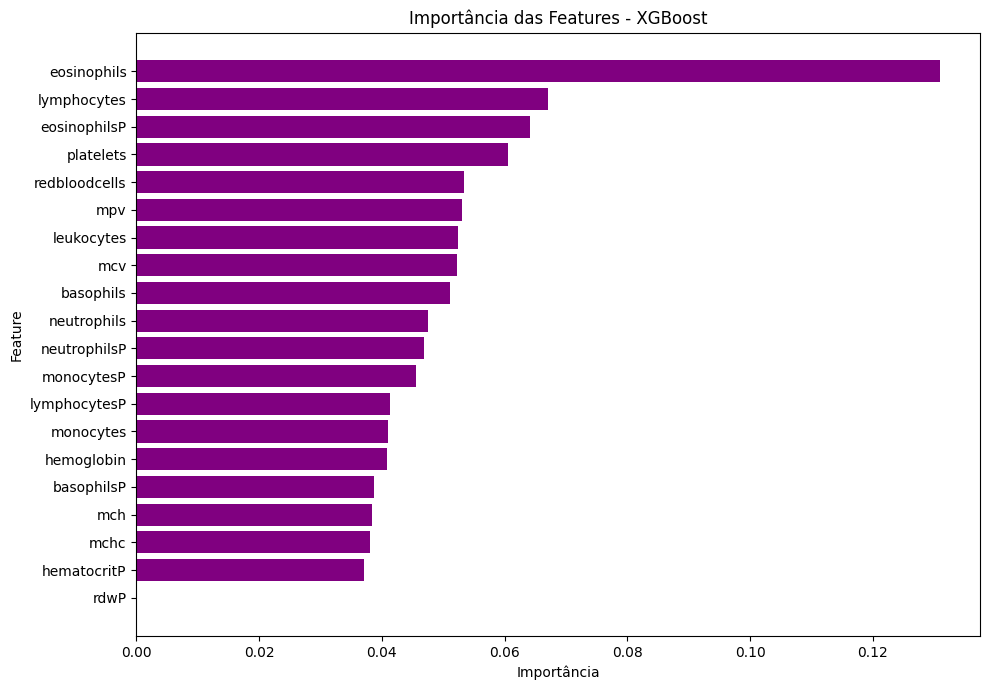

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
plt.title('Importância das Features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.8288
Precisão: 0.8083
Recall:   0.7939
F1-Score: 0.8002
MCC:      0.6020
AUC:      0.8622
--------------------------------------------------


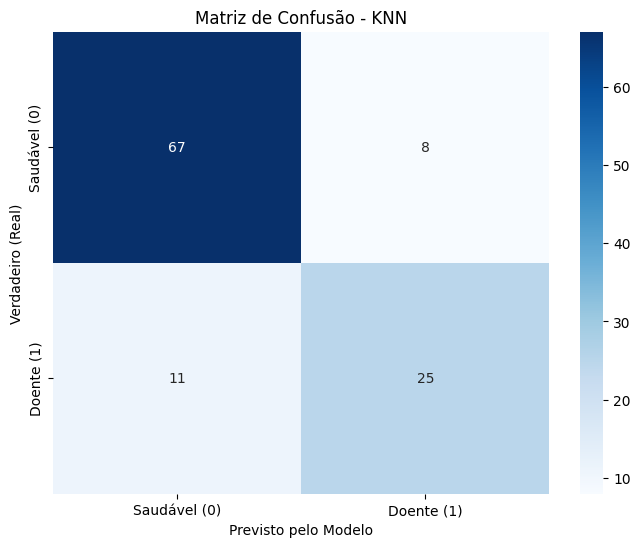

In [7]:
# Fazendo as Previsões
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [8]:
import os
import pandas as pd

nome_modelo = 'xgb'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo xgb salvas com sucesso!
